<a href="https://colab.research.google.com/github/bheemeshpujari63/user-segmentation/blob/main/User_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
data = pd.read_excel('/content/Online Retail.xlsx')
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [34]:
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [36]:
data.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
357771,568134,22107,PIZZA PLATE IN BOX,1,2011-09-23 17:02:00,3.29,NaN,United Kingdom
5155,536846,22625,RED KITCHEN SCALES,1,2010-12-02 19:59:00,8.50,14573.0,United Kingdom
197659,553923,21395,BLUE POLKADOT BEAKER,96,2011-05-20 09:30:00,0.39,13266.0,United Kingdom
429824,573576,22666,RECIPE BOX PANTRY YELLOW DESIGN,1,2011-10-31 14:09:00,5.79,14096.0,United Kingdom
168027,551010,22078,RIBBON REEL LACE DESIGN,1,2011-04-26 09:52:00,4.71,NaN,United Kingdom


In [37]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [38]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [39]:
def clean_selldata(df):
    # Remove rows without CustomerID
    df = df.dropna(subset=["CustomerID"])

    # Remove returns (negative or zero quantity)
    df = df[df["Quantity"] > 0]

    # Remove invalid prices
    df = df[df["UnitPrice"] > 0]

    # Create total transaction value
    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

    # Convert InvoiceDate to datetime
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

    return df

In [40]:
data_sell = clean_selldata(data)
data_sell

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [41]:
snapshot_date = data_sell["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [42]:
rfm = data_sell.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [43]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,307.415000
50%,51.000000,41.000000,674.485000
75%,142.000000,100.000000,1661.740000
max,374.000000,7847.000000,280206.020000


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [45]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm.columns
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.396578,8.358668
12347.0,-0.905340,0.394649,0.250966
12348.0,-0.175360,-0.265435,-0.028596
12349.0,-0.735345,-0.081836,-0.033012
12350.0,2.174578,-0.326635,-0.191347


In [46]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-3.965777e-01,-2.281344e-01
25%,-7.453445e-01,-3.266350e-01,-1.943495e-01
50%,-4.153533e-01,-2.217210e-01,-1.535104e-01
75%,4.946227e-01,3.619268e-02,-4.367134e-02
max,2.814561e+00,3.390157e+01,3.094634e+01


In [47]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)


KMeans(n_clusters=4, random_state=42)

In [48]:
rfm["Cluster"] = kmeans.labels_
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,182,4310.00,0
12348.0,75,31,1797.24,1
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


In [49]:
rfm["Cluster"].value_counts()

,count
Cluster,
0,2171
1,1326
3,828
2,13


In [50]:
cluster_summary = rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,20.990788,135.285122,2645.818172
1,98.218703,37.719457,773.877083
2,4.692308,2565.307692,126118.310000
3,272.407005,25.138889,605.842525


In [51]:
cluster_labels = {
    0: "High-Value Loyal Customers",
    1: "Churn Risk Customers",
    2: "New / Low Engagement Customers",
    3: "Regular Customers"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Regular Customers
12347.0,2,182,4310.00,0,High-Value Loyal Customers
12348.0,75,31,1797.24,1,Churn Risk Customers
12349.0,19,73,1757.55,0,High-Value Loyal Customers
12350.0,310,17,334.40,3,Regular Customers


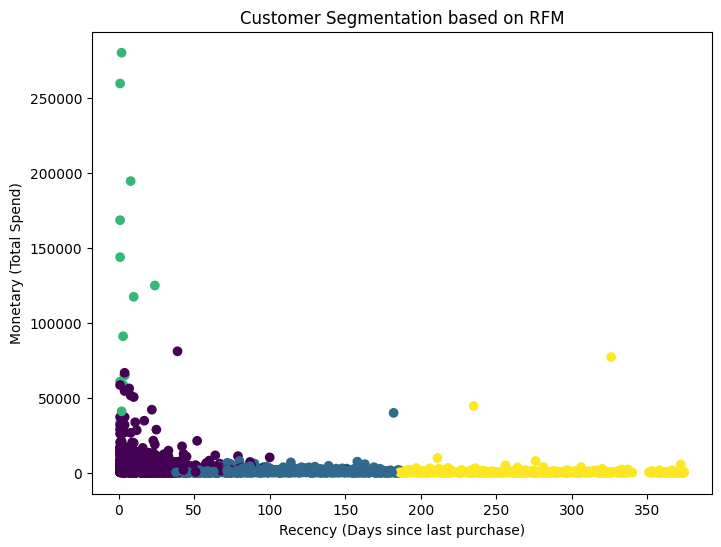

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel("Recency (Days since last purchase)")
plt.ylabel("Monetary (Total Spend)")
plt.title("Customer Segmentation based on RFM")
plt.show()

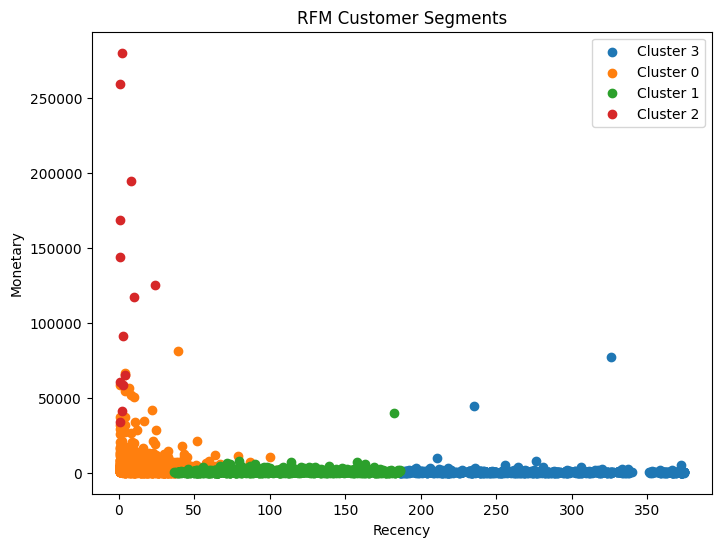

In [53]:
plt.figure(figsize=(8, 6))

for cluster in rfm["Cluster"].unique():
    subset = rfm[rfm["Cluster"] == cluster]
    plt.scatter(
        subset["Recency"],
        subset["Monetary"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.title("RFM Customer Segments")
plt.legend()
plt.show()